# **EQUIPO LFM** | Aprendizaje automatico

## Bibliotecas a utilizar en el cuaderno

In [537]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ShuffleSplit, cross_val_score
from mpl_toolkits.mplot3d import Axes3D


## Funciones

In [538]:
# @title
# funciones

# Optimización de K: Error vs. Número de Vecinos
def koptimomse(X_train, X_test, y_train, y_test):
  k_values = range(1, 21) # Probamos k desde 1 hasta 20
  errores_mse = []

  for k in k_values:
      # Entrenar modelo con el k actual
      modelo = KNeighborsRegressor(n_neighbors=k)
      modelo.fit(X_train, y_train)

      # Predecir y calcular el error
      predicciones = modelo.predict(X_test)
      mse = mean_squared_error(y_test, predicciones)
      errores_mse.append(mse)

  # Guardar resultados y graficar
  resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

  plt.figure(figsize=(10, 6))
  plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

  # Estética del gráfico
  plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
  plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
  plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
  plt.xticks(k_values) # Para ver todos los números del 1 al 20
  plt.grid(True, alpha=0.3)

  # Marcar el punto óptimo
  min_mse = min(errores_mse)
  best_k = k_values[errores_mse.index(min_mse)]
  plt.annotate(f'K para MSE mínimo teórico= {best_k}',
              xy=(best_k, min_mse),
              xytext=(best_k + 1, min_mse + 0.01),
              arrowprops=dict(facecolor='black', shrink=0.05))

  plt.show()
  print(f"El valor de K teórico con MSE mínimo es: {best_k}")
  return resultados, best_k


# Búsqueda del K con menor promedio de residuos
def koptimo_residuos(zona_estable, X_train, X_test, y_train, y_test):

  residuos_resultados = {}

  for i in range(len(zona_estable)):
      best_k = zona_estable[i]
      knn = KNeighborsRegressor(n_neighbors= best_k)
      knn.fit(X_train, y_train)
      y_pred = knn.predict(X_test)
      residuos = y_test - y_pred
      residuos_mean = residuos.mean()
      print(f"K: {best_k} | Prom residuos: {residuos_mean}")
      # print(f"Prom residuos: {residuos_mean}")
      residuos_resultados[best_k] = residuos_mean
  print("\n----------------\n")
  # Encontrar la clave asociada al valor mínimo
  best_k3 = min(residuos_resultados, key=residuos_resultados.get)

  # Obtener el valor mínimo usando esa clave
  min_residuo = residuos_resultados[best_k]

  print(f"Clave (K) con residuo mínimo: {best_k}")
  print(f"Valor del residuo mínimo: {min_residuo}")

  return best_k, min_residuo



# Cálculo de métricas de regresion
def regre(y_test, y_pred):
  # 1. Cálculo de métricas
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return mse, r2


# Grafico de regresion con resultados
def regrapho(y_test, y_pred):
  # llamado a funcion 'regre' para obtener metricas
  mse, r2 = regre(y_test, y_pred)

  # 2. Generación del gráfico
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

  # Configuración de etiquetas
  plt.xlabel('Valores Reales')
  plt.ylabel('Predicciones')
  plt.title('Real vs Predicho (KNN Regressor)')

  # 3. Agregar el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
  texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

  # Usamos plt.gca().text para posicionar el texto
  # transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
  plt.gca().text(0.95, 0.05, texto_metricas,
                transform=plt.gca().transAxes,
                fontsize=11,
                verticalalignment='bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

  plt.show()
  print(f"Mean Square Error: {mse}")
  print(f"R^2: {r2}")
  return mse, r2


# Función para Línea de Regresión 2D (Experimentos con 1 variable)
def graficar_linea_2d_knn(modelo, X, y, nombres_cols):
    """
    Genera un gráfico 2D con los puntos reales y la línea de predicción escalonada de KNN.
    X: DataFrame o Array con exactamente 1 columna.
    """
    plt.figure(figsize=(10, 6))

    # Datos reales
    x_data = X.iloc[:, 0] if hasattr(X, 'iloc') else X.flatten()
    plt.scatter(x_data, y, color='gray', alpha=0.5, label='Datos Reales')

    # Crear línea de predicción suave
    x_range = np.linspace(x_data.min(), x_data.max(), 500).reshape(-1, 1)

    # Manejo de nombres de columnas si es necesario
    if hasattr(X, 'columns'):
        import pandas as pd
        x_range_df = pd.DataFrame(x_range, columns=X.columns)
        y_pred = modelo.predict(x_range_df)
    else:
        y_pred = modelo.predict(x_range)

    plt.plot(x_range, y_pred, color='red', linewidth=2, label='Línea de Regresión KNN')

    plt.xlabel(nombres_cols[0])
    plt.ylabel(nombres_cols[1])
    plt.title('Análisis de Regresión KNN (2D)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Función para Superficie 3D (Experimentos con 2 variables)
def graficar_superficie_3d_knn(modelo, X, y, nombres_cols):
    """
    Genera un gráfico 3D con los puntos reales y la superficie de predicción de KNN.
    X: DataFrame o Array con exactamente 2 columnas.
    y: Series o Array con la variable objetivo.
    nombres_cols: Lista con [Nombre X1, Nombre X2, Nombre Y].
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Datos reales
    # Si X es DataFrame, usamos .iloc para evitar errores de índice
    x1_data = X.iloc[:, 0] if hasattr(X, 'iloc') else X[:, 0]
    x2_data = X.iloc[:, 1] if hasattr(X, 'iloc') else X[:, 1]
    ax.scatter(x1_data, x2_data, y, c='teal', marker='o', alpha=0.6, label='Datos Reales')

    # 2. Crear malla para la superficie de predicción
    x1_range = np.linspace(x1_data.min(), x1_data.max(), 30)
    x2_range = np.linspace(x2_data.min(), x2_data.max(), 30)
    X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)

    # Crear set de prueba para la malla
    malla_input = np.c_[X1_mesh.ravel(), X2_mesh.ravel()]

    # Predicción sobre la malla
    # Nota: Si el modelo se entrenó con nombres de columnas, convertimos a DF
    if hasattr(X, 'columns'):
        import pandas as pd
        malla_df = pd.DataFrame(malla_input, columns=X.columns)
        Z_mesh = modelo.predict(malla_df).reshape(X1_mesh.shape)
    else:
        Z_mesh = modelo.predict(malla_input).reshape(X1_mesh.shape)

    # 3. Graficar superficie
    surf = ax.plot_surface(X1_mesh, X2_mesh, Z_mesh, cmap='viridis', alpha=0.4, edgecolor='none')

    ax.set_xlabel(nombres_cols[0])
    ax.set_ylabel(nombres_cols[1])
    ax.set_zlabel(nombres_cols[2])
    plt.title(f'Superficie de Regresión KNN (3D)')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()


def graficar_histograma_residuos(y_real, y_pred):
    """
    Grafica la distribución de los errores (residuos).
    y_real: Valores verdaderos del set de test.
    y_pred: Predicciones hechas por el modelo KNN.
    """
    residuos = y_real - y_pred

    plt.figure(figsize=(10, 6))
    sns.histplot(residuos, kde=True, color='salmon', bins=20)

    # Línea de referencia en el cero
    plt.axvline(x=0, color='black', linestyle='--', label='Error Cero')

    plt.title('Distribución de Residuos (Errores del Modelo KNN)', fontsize=14)
    plt.xlabel('Valor del Error (Real - Predicho)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Diagnóstico rápido
    print(f"Sesgo promedio (Media de residuos): {residuos.mean():.4f}")

# función para encontrar zona de estabilidad de K
def zona_estabilidad_continua(df, umbral_p2p=0.005):
    """
    df: DataFrame con columnas 'k' y 'MSE'
    umbral_p2p: Máxima diferencia permitida entre un K y el siguiente
    """
    # 1. Calculamos la diferencia absoluta punto a punto
    # Shift(-1) nos permite comparar K con K+1
    df = df.sort_values('k').copy()
    df['diff_next'] = df['MSE'].diff().abs().shift(-1)

    # 2. Creamos una máscara de "puntos estables"
    # Un punto es estable si su diferencia con el siguiente es baja
    df['es_estable'] = df['diff_next'] < umbral_p2p

    # 3. Identificar bloques continuos (Islas de estabilidad)
    # Cada vez que 'es_estable' cambia de True a False, incrementamos un ID de grupo
    df['group_id'] = (df['es_estable'] != df['es_estable'].shift()).cumsum()

    # 4. Filtrar solo los grupos que son estables y tienen al menos N elementos
    estables = df[df['es_estable'] == True]

    if estables.empty:
        return []

    # 5. Elegir el bloque de estabilidad más relevante
    # Opción A: El bloque más largo
    # Opción B: El bloque que contiene el MSE mínimo (recomendado)
    k_min_mse = df.loc[df['MSE'].idxmin(), 'k']

    # Buscamos qué grupos están cerca del K mínimo o son los más largos
    id_grupo_optimo = None
    max_len = 0

    for g_id, group in estables.groupby('group_id'):
        # Incluimos el último elemento del enlace (si 12->13 es estable, el grupo debe incluir 13)
        ks_del_grupo = group['k'].tolist()
        ultimo_k = ks_del_grupo[-1] + 1
        if ultimo_k in df['k'].values:
            ks_del_grupo.append(ultimo_k)

        if len(ks_del_grupo) > max_len:
            max_len = len(ks_del_grupo)
            mejor_zona = ks_del_grupo

    return mejor_zona

## Data acquisition - Creación de un dataframe a partir del archivo csv

In [539]:
dfIris = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSLgU6YF5djPgcJvcmXyqdIjfVefPsYlj6HUnRH15sZwsEL4GX7KPY-c3CWgM3n8vCljid-ZPocdAAl/pub?output=csv')

## Preprocesamiento

### Feature Scaling
- No se hace uso de un StandardScaler o MinMaxScaler para unificar las escalas porque en el dataset estas ya estan informadas en la misma escala (centímetros).

### Header standarization & data cleaning

- Renombraremos las columnas al español, y eliminaremos la columan Id ya que no será utilizada para el análisis

In [540]:
#Renombrado de columnas
dfIris.rename({'SepalLengthCm':'sepalo_largo',
           'SepalWidthCm':'sepalo_ancho',
           'PetalLengthCm':'petalo_largo',
           'PetalWidthCm':'petalo_ancho',
           'Species':'especies'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

dfIris.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna


Inspección de la forma del df

In [541]:
dfIris.shape

(150, 5)

Visualización del segmento inicial y final de los datos

In [542]:
dfIris

,sepalo_largo,sepalo_ancho,petalo_largo,petalo_ancho,especies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Matriz de Correlación

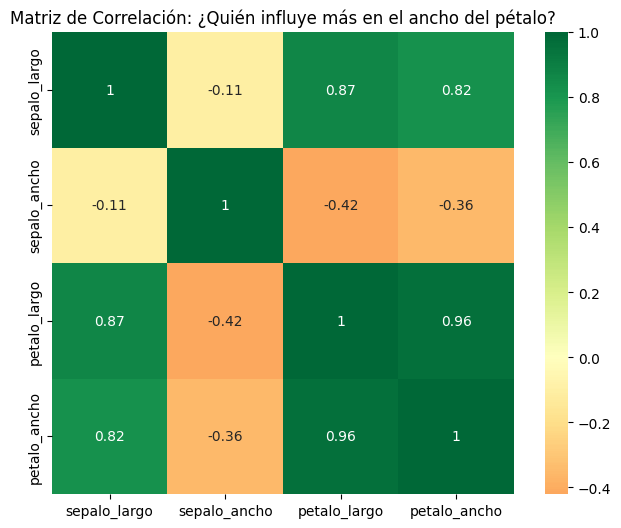

In [543]:
# 1. Calculamos la correlación de las columnas numéricas
matriz_corr = dfIris.drop(columns=['especies']).corr()

# 2. Generamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, square=True)

plt.title('Matriz de Correlación: ¿Quién influye más en el ancho del pétalo?')
plt.show()

### Conclusiones parciales:

- Largo del pétalo: Según se observa en la matriz de correlación es la variable con mayor correlación.
- Largo del sépalo: Esta variable también tiene una alta correlación con el ancho del petalo.
- Ancho del sépalo: Esta variable tiene una correlación muy baja e incluso negativa.

Estas correlaciones analíticas tienen coherencia biológica, dado que los petalos crecen en ambas direcciones, a lo largo y a lo ancho. A su vez, los sépalos (cáliz, exterior) y pétalos (corola, interior) son hojas modificadas que forman el perianto que tiene una función de protección de los organos sexuales y de atracción de polinizadores y en el desarrollo temprano del capullo, los sépalos actúan como cobertura protectora del pétalo.

## Estudio de impacto de la dimensionalidad en los entrenamientos

Se procede a entrenar modelos con cantidades diferentes sucesivas de dimensiones y evaluar su rendimiento.



## Tres dimensiones

- Largo del pétalo
- Ancho del sépalo
- Largo del sépalo



### Particionamiento

In [544]:
X3 = dfIris.drop(['petalo_ancho', 'especies'], axis=1)
y = dfIris['petalo_ancho']

In [545]:
# 2. División en entrenamiento y prueba
X_train3, X_test3, y_train3, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

### Búsqueda de K óptimo - Holdout - K vs MSE

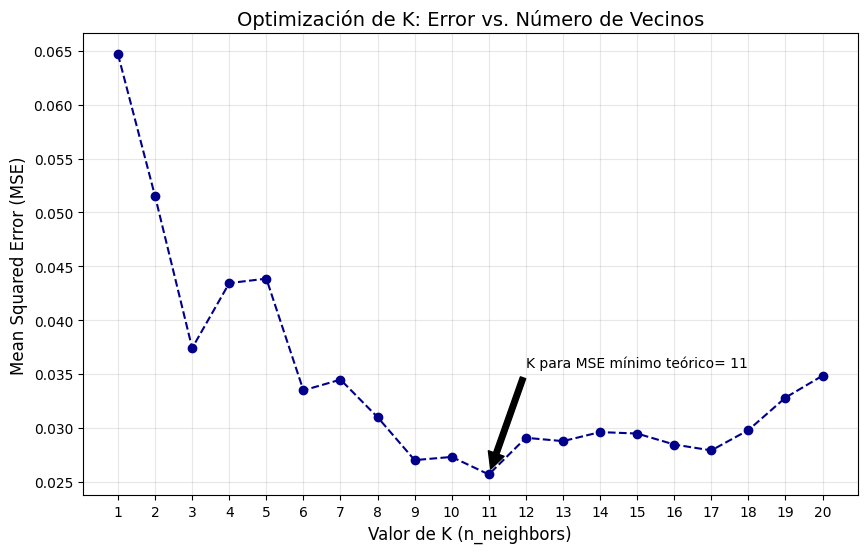

El valor de K teórico con MSE mínimo es: 11


In [546]:
resultados_k3, best_k3_teorico = koptimomse(X_train3, X_test3, y_train3, y_test)

In [547]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k3 = zona_estabilidad_continua(resultados_k3, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k3}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k3, min_residuo_3 = koptimo_residuos(zona_estable_k3, X_train3, X_test3, y_train3, y_test)

Rango de K en zona de estabilidad continua: [12, 13, 14, 15, 16, 17]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 12 | Prom residuos: 0.04138888888888881
K: 13 | Prom residuos: 0.03641025641025633
K: 14 | Prom residuos: 0.02761904761904755
K: 15 | Prom residuos: 0.025555555555555463
K: 16 | Prom residuos: 0.020624999999999994
K: 17 | Prom residuos: 0.019803921568627467

----------------

Clave (K) con residuo mínimo: 17
Valor del residuo mínimo: 0.019803921568627467


### Implementación de KNN Regresor

In [548]:
knn_3 = KNeighborsRegressor(n_neighbors=best_k3)
knn_3.fit(X_train3, y_train3)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Predicciones

In [549]:
y_pred3 = knn_3.predict(X_test3)

### Evaluación del modelo - Resultados (Graficando Línea de Identidad)

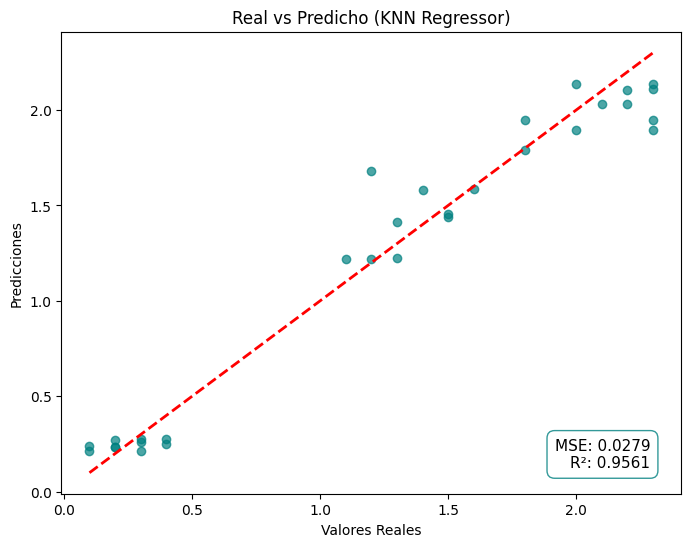

Mean Square Error: 0.027904267589388698
R^2: 0.9561015909551822


In [550]:
mse3, r2_3 = regrapho(y_test, y_pred3)

### Histograma de Residuos

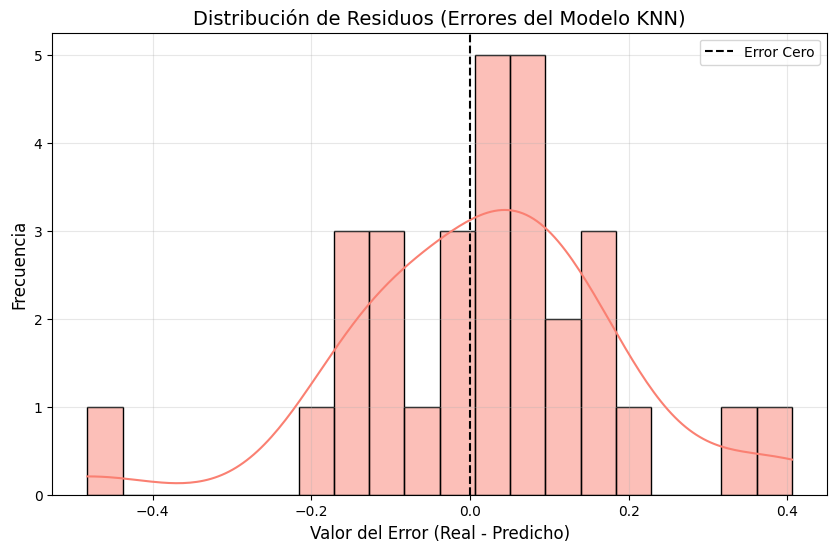

Sesgo promedio (Media de residuos): 0.0198


In [551]:
graficar_histograma_residuos(y_test, y_pred3)

## Dos dimensiones


### Particionamiento A

Para el primer experimento con dos dimensiones tomamos una variable con fuerte correlación y otra de correlación débil con respecto a nuetra variable objetivo

- Largo del pétalo
- Ancho del sépalo

In [552]:
X2a = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo'], axis=1)
nombres_2a = ['Largo del pétalo', 'Ancho del sépalo', 'Petalo ancho']

In [553]:
# 2. División en entrenamiento y prueba
X_train2a, X_test2a, y_train2a, y_test = train_test_split(X2a, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

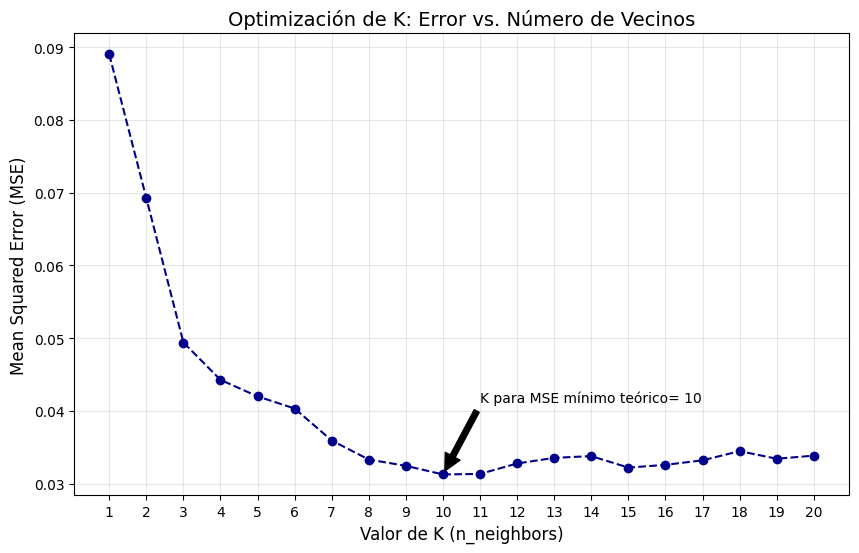

El valor de K teórico con MSE mínimo es: 10


In [554]:
resultados_k2a, best_k2a_teorico = koptimomse(X_train2a, X_test2a, y_train2a, y_test)

In [555]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k2a = zona_estabilidad_continua(resultados_k2a, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k2a}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k2a, min_residuo_2a = koptimo_residuos(zona_estable_k2a, X_train2a, X_test2a, y_train2a, y_test)

Rango de K en zona de estabilidad continua: [8, 9, 10, 11]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 8 | Prom residuos: 0.04958333333333331
K: 9 | Prom residuos: 0.044814814814814766
K: 10 | Prom residuos: 0.04566666666666662
K: 11 | Prom residuos: 0.04060606060606057

----------------

Clave (K) con residuo mínimo: 11
Valor del residuo mínimo: 0.04060606060606057


#### Implementación KNN Regressor

In [556]:
knn_2a = KNeighborsRegressor(n_neighbors=best_k2a)
knn_2a.fit(X_train2a, y_train2a)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Predicciones

In [557]:
y_pred2a = knn_2a.predict(X_test2a)

#### Evaluación del modelo - Resultados (Graficando Línea de Identidad)



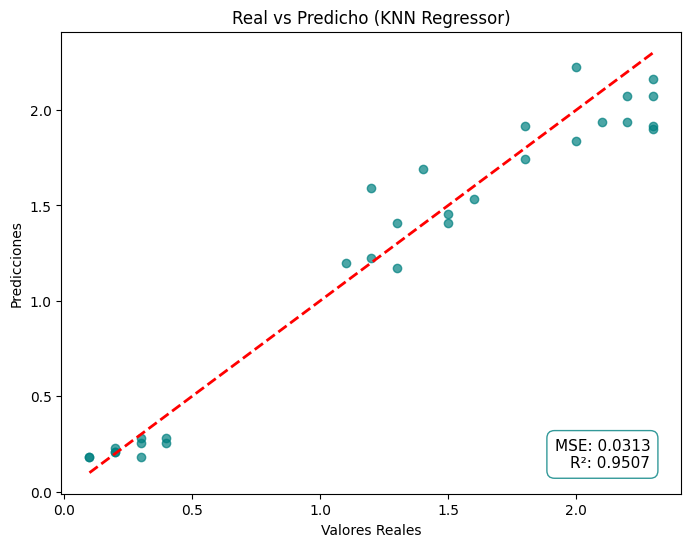

Mean Square Error: 0.03134435261707987
R^2: 0.9506897212757226


In [558]:
mse2a, r2_2a = regrapho(y_test, y_pred2a)

#### Gráfico de Línea de Regresión

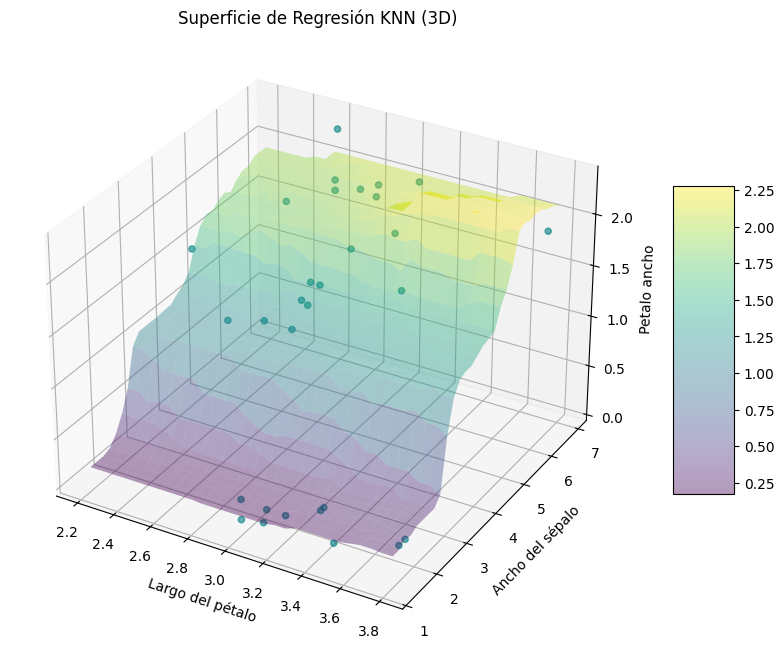

In [559]:
graficar_superficie_3d_knn(knn_2a, X_test2a, y_test, nombres_2a)

#### Histograma de Residuos

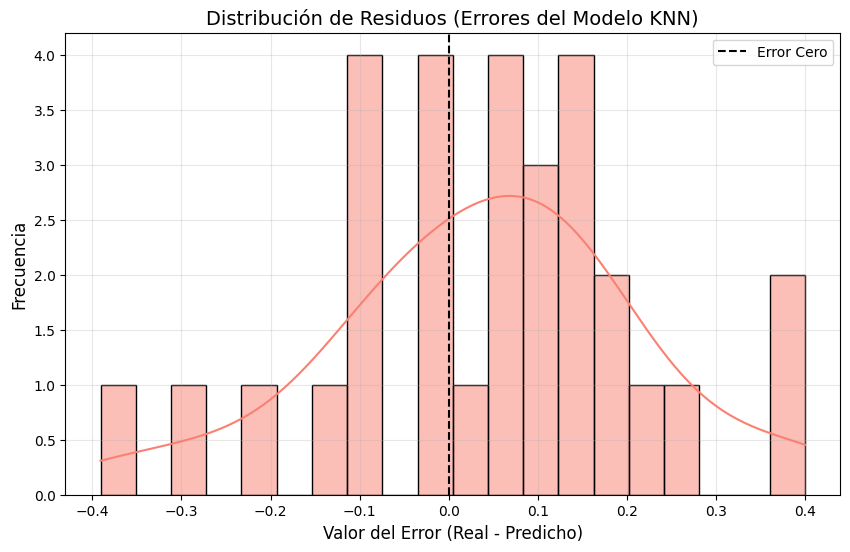

Sesgo promedio (Media de residuos): 0.0406


In [560]:
graficar_histograma_residuos(y_test, y_pred2a)

### Particionamiento b

En el segundo experimento de dos dimensiones tomamos las dos variables que tienen fuerte correlación con nuestra variable objetivo

- Largo pétalo
- Largo sépalo

In [561]:
X2b = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_ancho'], axis=1)
nombres_2b = ['Largo del pétalo', 'Largo del sépalo', 'Petalo ancho']

In [562]:
# 2. División en entrenamiento y prueba
X_train2b, X_test2b, y_train2b, y_test = train_test_split(X2b, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

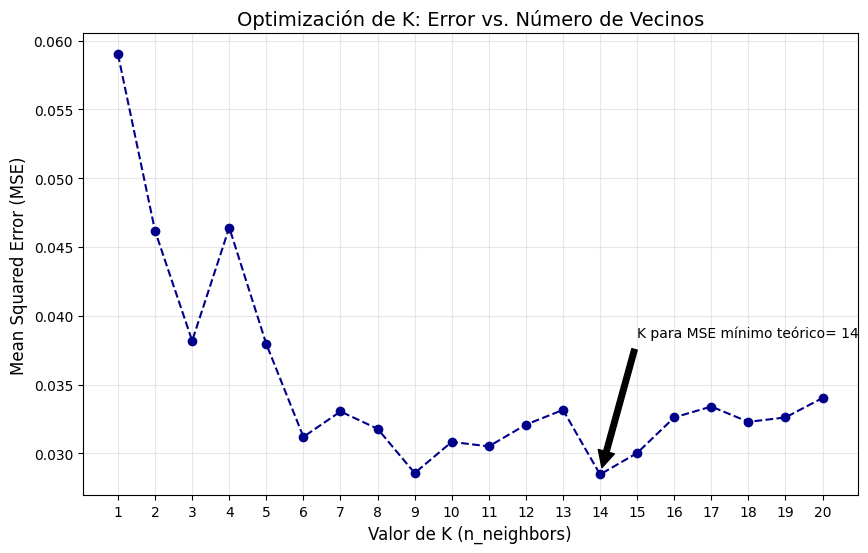

El valor de K teórico con MSE mínimo es: 14


In [563]:
resultados_k2b, best_k2b = koptimomse(X_train2b, X_test2b, y_train2b, y_test)

In [564]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k2b = zona_estabilidad_continua(resultados_k2b, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k2b}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k2b, min_residuo_2b = koptimo_residuos(zona_estable_k2b, X_train2b, X_test2b, y_train2b, y_test)

Rango de K en zona de estabilidad continua: [16, 17, 18, 19]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 16 | Prom residuos: 0.02062499999999999
K: 17 | Prom residuos: 0.023921568627450932
K: 18 | Prom residuos: 0.022037037037037004
K: 19 | Prom residuos: 0.02175438596491227

----------------

Clave (K) con residuo mínimo: 19
Valor del residuo mínimo: 0.02175438596491227


#### Implementación KNN Regressor

In [565]:
knn_2b = KNeighborsRegressor(n_neighbors=best_k2b)
knn_2b.fit(X_train2b, y_train2b)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Predicciones

In [566]:
y_pred2b = knn_2b.predict(X_test2b)

#### Evaluación del modelo - Resultados

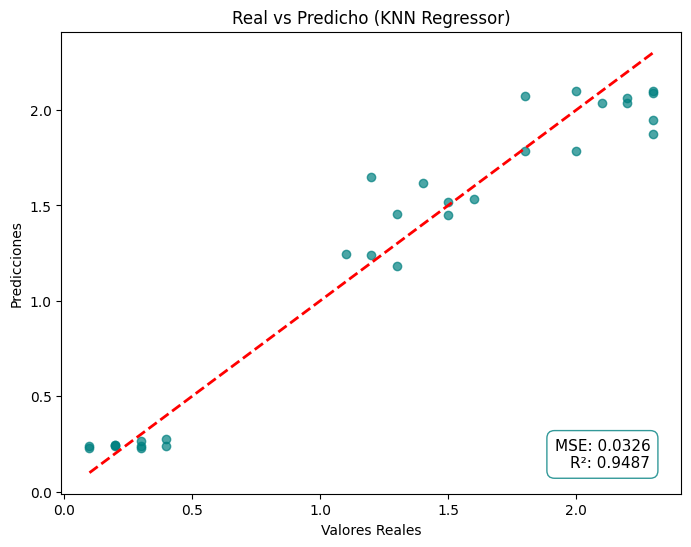

Mean Square Error: 0.03261495844875346
R^2: 0.9486908308065547


In [567]:
mse2b, r2_2b = regrapho(y_test, y_pred2b)


#### Gráfico de Línea de Regresión

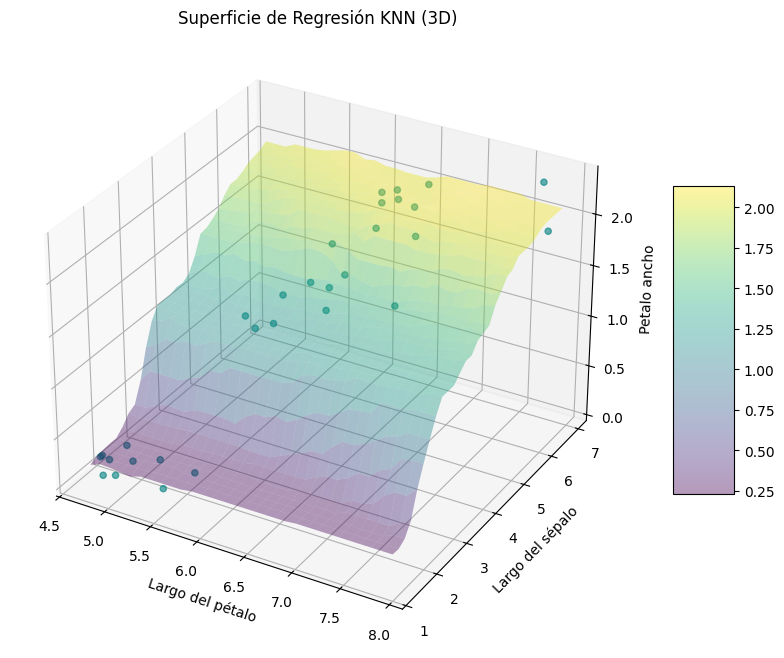

In [568]:
graficar_superficie_3d_knn(knn_2b, X_test2b, y_test, nombres_2b)

#### Histograma de Residuos

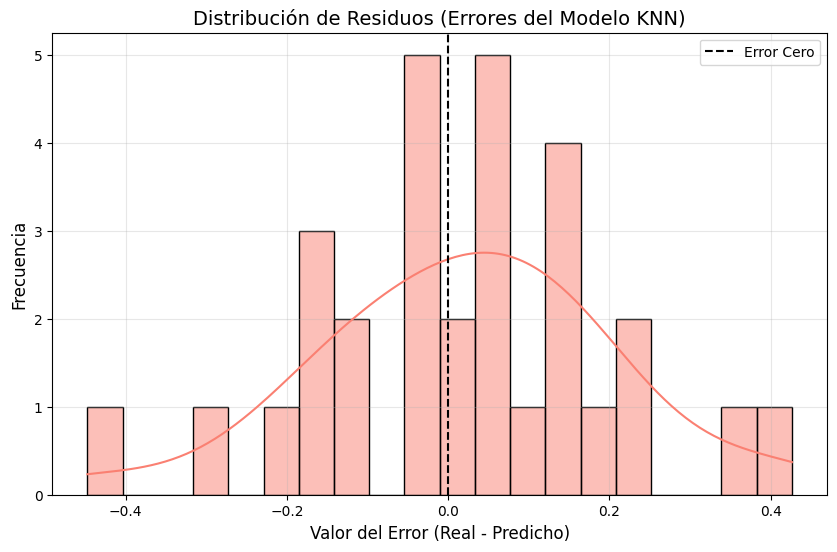

Sesgo promedio (Media de residuos): 0.0218


In [569]:
graficar_histograma_residuos(y_test, y_pred2b)

La diferencia en los valores de $k$ (10 vs 14) se debe a cómo cambian las "vecindades" en el espacio multidimensional cuando cambiamos las variables.

 Experimento 1: Fuerte (+) y Negativa (-) ($k=10$)Al combinar una variable que "empuja" en la misma dirección que el objetivo (largo del pétalo) con una que "tira" en contra (ancho del sépalo), estamos creando un espacio con mucha estructura y contraste. El efecto: Las especies de flores quedan muy separadas entre sí. Como la separación es clara y hay "contraste" gracias a la variable negativa, el modelo encuentra el punto de equilibrio rápido. Por qué $k=10$: Necesitamos menos vecinos para promediar porque la estructura es robusta; hay menos ambigüedad en quién es vecino de quién.

 Experimento 2: Dos Fuertes (+) ($k=14$)Al usar dos variables con fuerte correlación (ej. largo del pétalo y largo del sépalo), tenemos redundancia. Ambas variables dicen casi lo mismo. El efecto: Esto crea lo que se llama "densidad" o "ruido de redundancia". Los puntos están muy pegados y las fronteras entre grupos de flores se vuelven más borrosas porque ambas variables escalan igual. Por qué $k=14$: Al haber más "amontonamiento" de datos que dicen lo mismo, el modelo necesita un $k$ más alto para suavizar la predicción. Un $k$ mayor ayuda a ignorar las pequeñas fluctuaciones de esos datos redundantes y a obtener un promedio más estable.

 En resumen:

 - Con contraste (+ y -): El modelo es más "decidido" y necesita mirar a menos vecinos para acertar.

 - Con redundancia (+ y +): El modelo se vuelve más "indeciso" porque los datos se parecen demasiado entre sí, y necesita ampliar el círculo de búsqueda ($k$ más alto) para estar seguro de la predicción.

## Una dimension


### Particionamiento a

En este primer experimento de una sola dimensión comenzamos primero con la variable de correlación más fuerte

- Largo del pétalo

In [570]:
X1a = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo', 'sepalo_ancho'], axis=1)
nombres_1a = ['Largo del pétalo', 'Petalo ancho']

In [571]:
# 2. División en entrenamiento y prueba
X_train1a, X_test1a, y_train1a, y_test = train_test_split(X1a, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

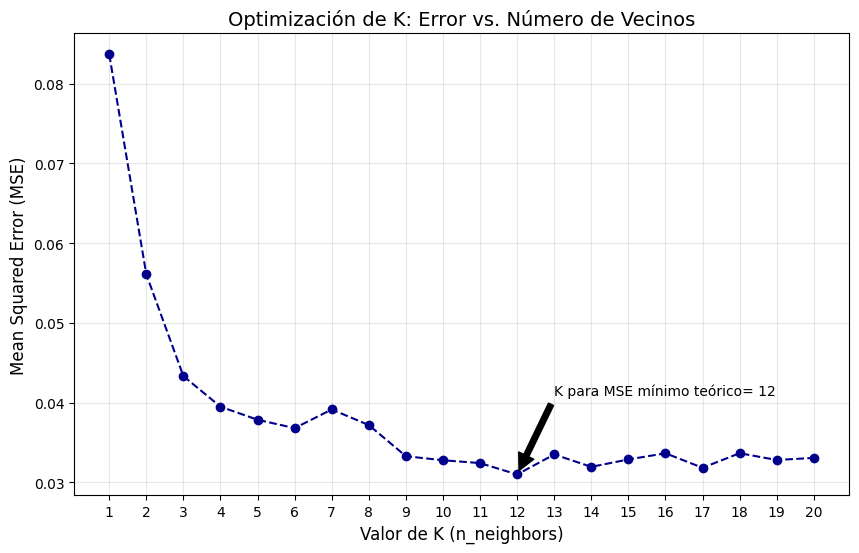

El valor de K teórico con MSE mínimo es: 12


In [572]:
resultados_1a, best_k1a = koptimomse(X_train1a, X_test1a, y_train1a, y_test)

In [573]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1a = zona_estabilidad_continua(resultados_1a, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1a}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1a, min_residuo_1a = koptimo_residuos(zona_estable_1a, X_train1a, X_test1a, y_train1a, y_test)

Rango de K en zona de estabilidad continua: [9, 10, 11]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 9 | Prom residuos: 0.030740740740740787
K: 10 | Prom residuos: 0.027333333333333334
K: 11 | Prom residuos: 0.03181818181818176

----------------

Clave (K) con residuo mínimo: 11
Valor del residuo mínimo: 0.03181818181818176


#### Implementación de KNN Regressor

In [574]:
knn_1a = KNeighborsRegressor(n_neighbors=best_k1a)
knn_1a.fit(X_train1a, y_train1a)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Predicciones

In [575]:
y_pred1a = knn_1a.predict(X_test1a)

#### Evaluación del modelo - Resultados


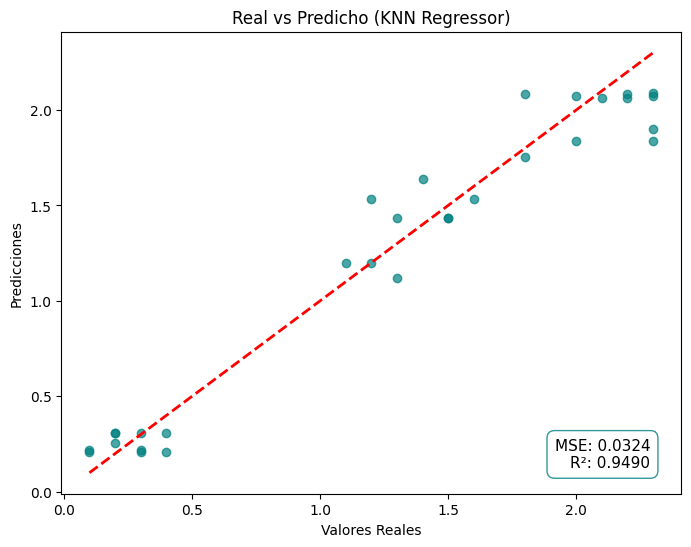

Mean Square Error: 0.03243250688705233
R^2: 0.948977859780197


In [576]:
mse1a, r2_1a = regrapho(y_test, y_pred1a)

#### Gráfico de Línea de Regresión

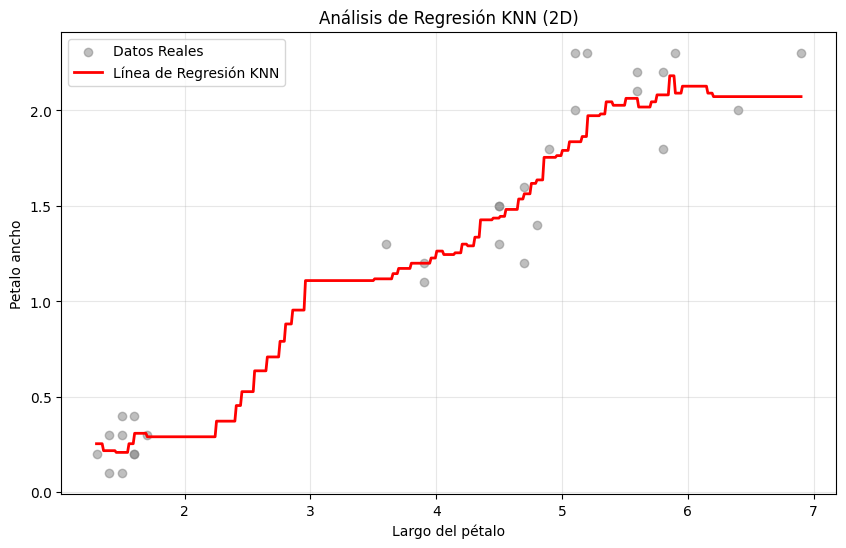

In [577]:
graficar_linea_2d_knn(knn_1a, X_test1a, y_test, nombres_1a)

#### Histograma de Residuos

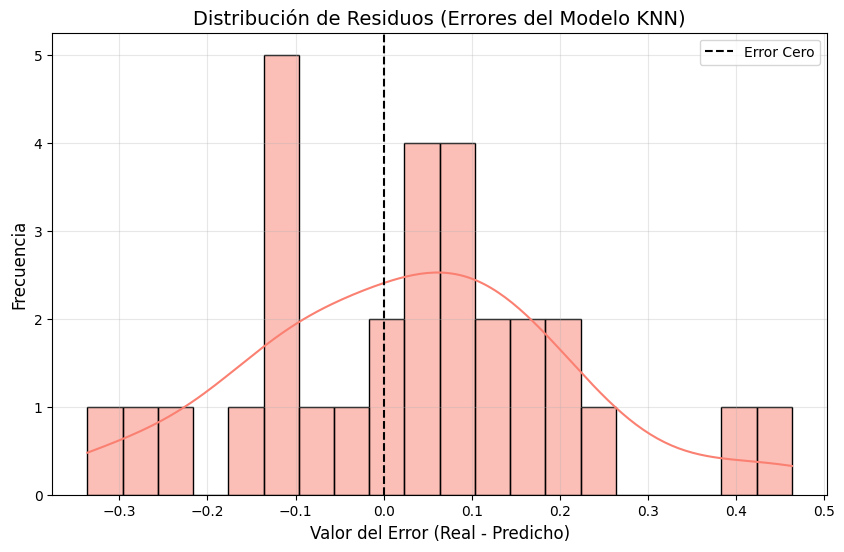

Sesgo promedio (Media de residuos): 0.0318


In [578]:
graficar_histograma_residuos(y_test, y_pred1a)

### Particionamiento b
En el segundo experimento de una sola dimensión tomamos la segunda variable de correlación más fuerte

- Largo del sépalo

In [579]:
X1b = dfIris.drop(['petalo_ancho', 'especies', 'petalo_largo', 'sepalo_ancho'], axis=1)
nombres_1b = ['Largo del sépalo', 'Sepalo largo']

In [580]:
# 2. División en entrenamiento y prueba
X_train1b, X_test1b, y_train1b, y_test = train_test_split(X1b, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

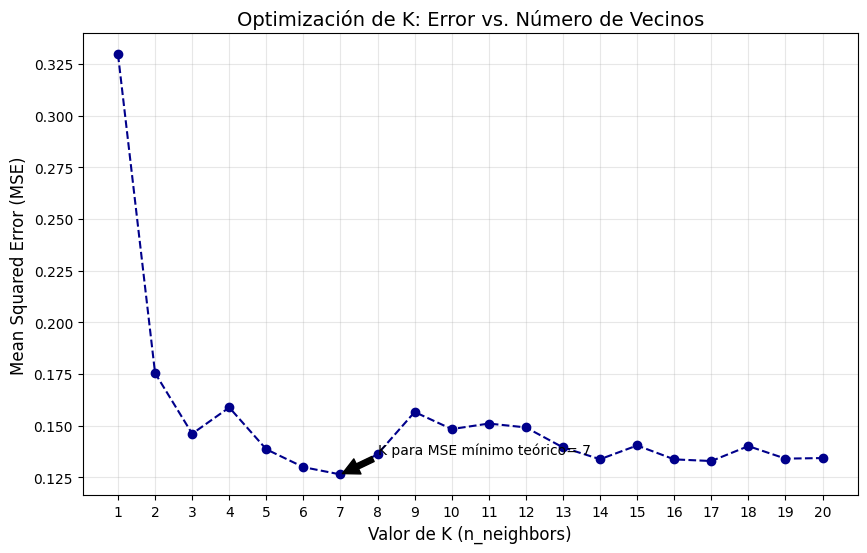

El valor de K teórico con MSE mínimo es: 7


In [581]:
resultados_1b, best_k1b = koptimomse(X_train1b, X_test1b, y_train1b, y_test)

In [582]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1b = zona_estabilidad_continua(resultados_1b, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1b}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1b, min_residuo_1b = koptimo_residuos(zona_estable_1b, X_train1b, X_test1b, y_train1b, y_test)

Rango de K en zona de estabilidad continua: [16, 17]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 16 | Prom residuos: -0.06395833333333328
K: 17 | Prom residuos: -0.05333333333333327

----------------

Clave (K) con residuo mínimo: 17
Valor del residuo mínimo: -0.05333333333333327


#### Implementación de KNN Regressor

In [583]:
knn_1b = KNeighborsRegressor(n_neighbors=best_k1b)
knn_1b.fit(X_train1b, y_train1b)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Predicciones

In [584]:
y_pred1b = knn_1b.predict(X_test1b)

#### Evaluación del modelo - Resultados


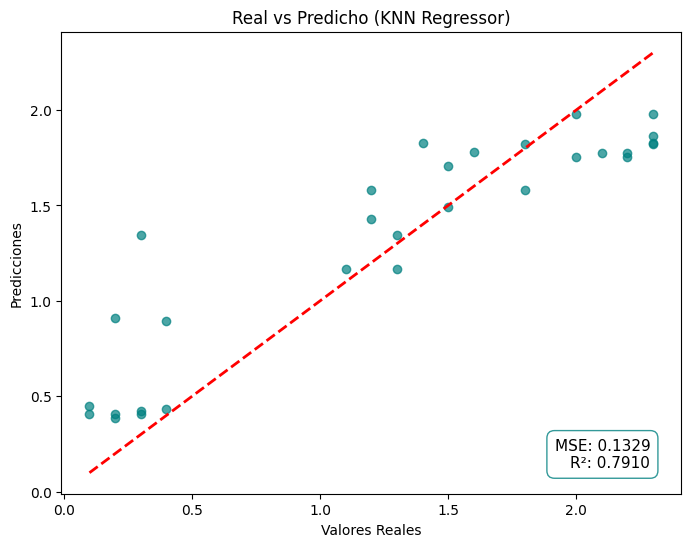

Mean Square Error: 0.13287658592848903
R^2: 0.7909613394122601


In [585]:
mse1b, r2_1b = regrapho(y_test, y_pred1b)

#### Gráfico de Línea de Regresión

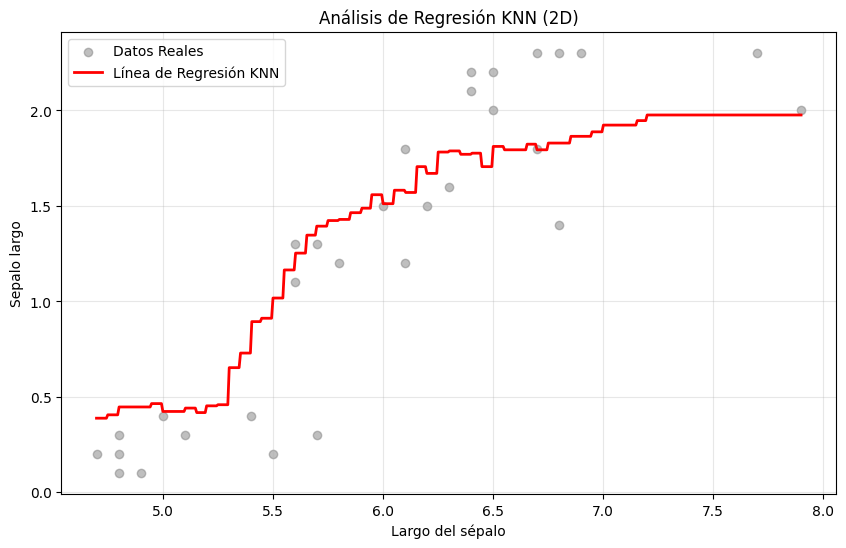

In [586]:
graficar_linea_2d_knn(knn_1b, X_test1b, y_test, nombres_1b)

#### Histograma de Residuos

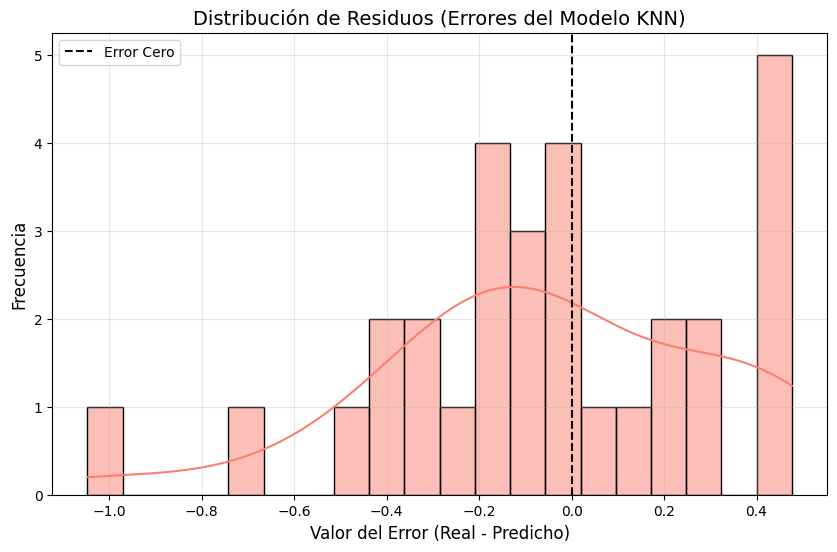

Sesgo promedio (Media de residuos): -0.0533


In [587]:
graficar_histograma_residuos(y_test, y_pred1b)

### Particionamiento c
En el tercer experimento de una sola dimensión tomamos la variable de correlación débil

- Ancho del sépalo

In [588]:
X1c = dfIris.drop(['petalo_ancho', 'especies', 'petalo_largo', 'sepalo_largo'], axis=1)
nombres_1c = ['Ancho del sépalo', 'Sepalo ancho']

In [589]:
# 2. División en entrenamiento y prueba
X_train1c, X_test1c, y_train1c, y_test = train_test_split(X1c, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

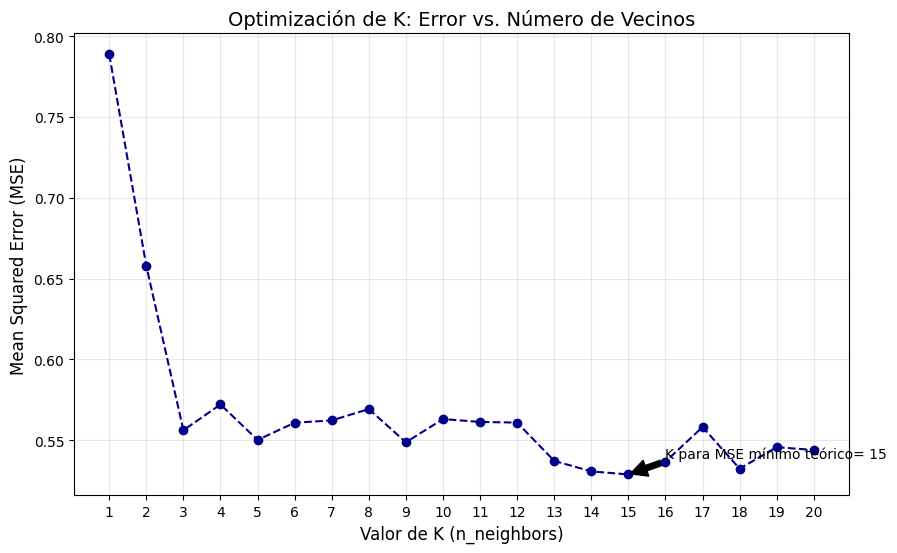

El valor de K teórico con MSE mínimo es: 15


In [590]:
resultados_1c, best_k1c = koptimomse(X_train1c, X_test1c, y_train1c, y_test)

In [591]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1c = zona_estabilidad_continua(resultados_1c, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1c}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1a, min_residuo_1a = koptimo_residuos(zona_estable_1c, X_train1c, X_test1c, y_train1c, y_test)

Rango de K en zona de estabilidad continua: [11, 12]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 11 | Prom residuos: -0.0493939393939394
K: 12 | Prom residuos: -0.0866666666666666

----------------

Clave (K) con residuo mínimo: 12
Valor del residuo mínimo: -0.0866666666666666


#### Implementación de KNN Regressor

In [592]:
knn_1c = KNeighborsRegressor(n_neighbors=best_k1c)
knn_1c.fit(X_train1c, y_train1c)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Predicciones

In [593]:
y_pred1c = knn_1c.predict(X_test1c)

#### Evaluación del modelo - Resultados

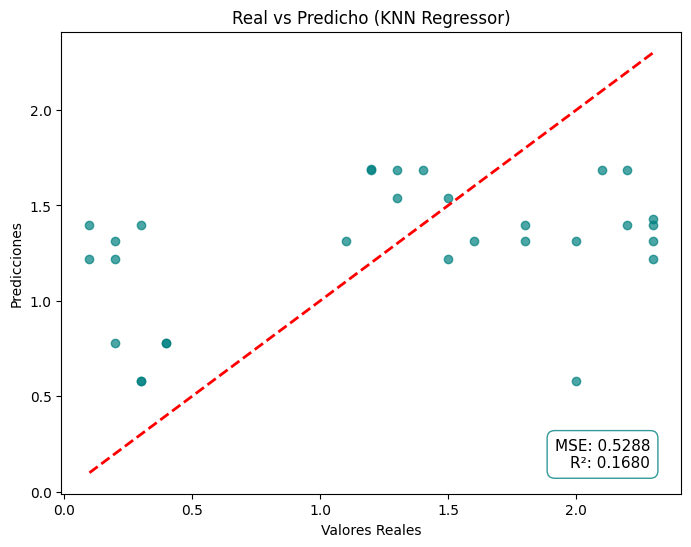

Mean Square Error: 0.5288414814814815
R^2: 0.16803766307166124


In [594]:
mse1c, r2_1c = regrapho(y_test, y_pred1c)

#### Gráfico de Línea de Regresión

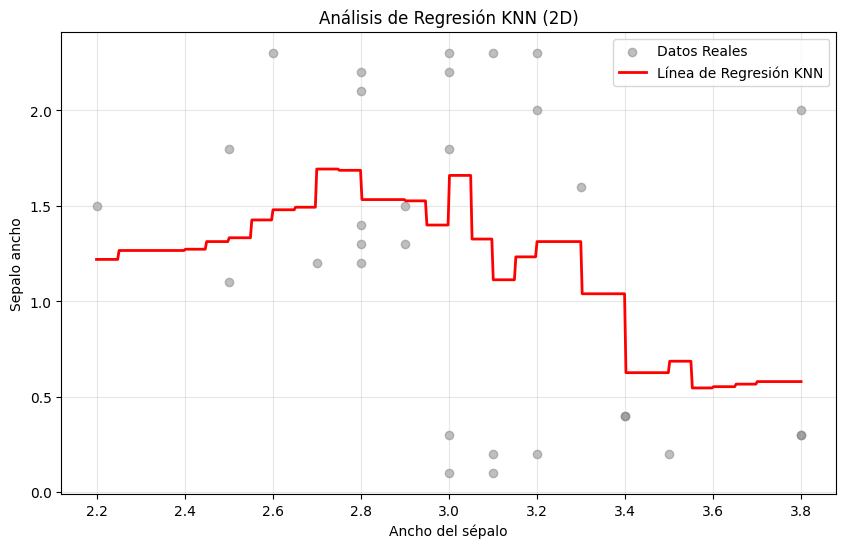

In [595]:
graficar_linea_2d_knn(knn_1c, X_test1c, y_test, nombres_1c)

#### Histograma de Residuos

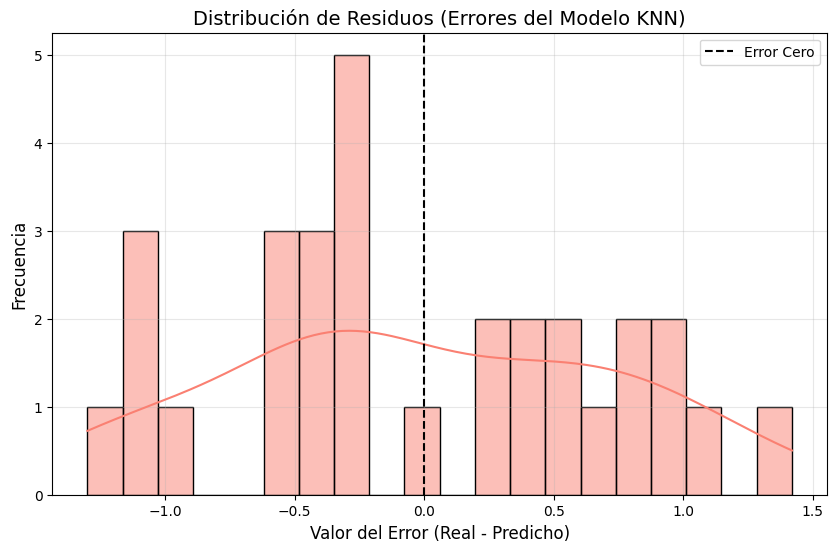

Sesgo promedio (Media de residuos): -0.0191


In [596]:
graficar_histograma_residuos(y_test, y_pred1c)

# Comparaciones

A fin de observar el impacto de la exploración de K óptimos, se procede a obtener los valores de R^2 y MSE para todas las dimensionalidades usando el valor teórico de K acorde al tamaño del dataset (K = 12).

Con todos los datos se crea una tabla para poder realizar las comparaciones correspondientes.

In [597]:
knn = KNeighborsRegressor(n_neighbors=12)

knn.fit(X_train3, y_train3)
y_pred_12n_3 = knn.predict(X_test3)
mse_12n_3, r2_12n_3 = regre(y_test, y_pred_12n_3)

knn.fit(X_train2a, y_train2a)
y_pred_12n_2a = knn.predict(X_test2a)
mse_12n_2a, r2_12n_2a = regre(y_test, y_pred_12n_2a)

knn.fit(X_train2b, y_train2b)
y_pred_12n_2b = knn.predict(X_test2b)
mse_12n_2b, r2_12n_2b = regre(y_test, y_pred_12n_2b)

knn.fit(X_train1a, y_train1a)
y_pred_12n_1a = knn.predict(X_test1a)
mse_12n_1a, r2_12n_1a = regre(y_test, y_pred_12n_1a)

knn.fit(X_train1b, y_train1b)
y_pred_12n_1b = knn.predict(X_test1b)
mse_12n_1b, r2_12n_1b = regre(y_test, y_pred_12n_1b)

knn.fit(X_train1c, y_train1c)
y_pred_12n_1c = knn.predict(X_test1c)
mse_12n_1c, r2_12n_1c = regre(y_test, y_pred_12n_1c)

In [598]:
# Creamos un diccionario con los resultados
data = {
    "Dimensiones": ["1dim-partA", "1dim-partB", "1dim-partC", "2dim-partA", "2dim-partB", "3 dimensiones"],
    "| ": ['| '] * 6,
    "K optimo": [best_k1a, best_k1b, best_k1c, best_k2a, best_k2b, best_k3],
    " ": [' '] * 6,
    "MSE": [mse1a, mse1b, mse1c, mse2a, mse2b, mse3],
    "R² Score": [r2_1a, r2_1b, r2_1c, r2_2a, r2_2b, r2_3],
    " | ": ['| '] * 6,
    "K teórico": ['12 '] * 6 ,
    " MSE": [mse1a, mse1b, mse1c, mse_12n_2a, mse_12n_2b, mse_12n_3],
    " R² Score": [r2_1a, r2_1b, r2_1c, r2_12n_2a, r2_12n_2b, r2_12n_3]
}

data = {
    "Dimensiones": ["3 dimensiones", "2dim-partA", "2dim-partB", "1dim-partA", "1dim-partB", "1dim-partC"],
    "| ": ['| '] * 6,
    "K optimo": [best_k3, best_k2a, best_k2b, best_k1a, best_k1b, best_k1c],
    " ": [' '] * 6,
    "MSE": [mse3, mse2a, mse2b, mse1a, mse1b, mse1c],
    "R² Score": [r2_3, r2_2a, r2_2b, r2_1a, r2_1b, r2_1c],
    " | ": ['| '] * 6,
    "K teórico": ['12 '] * 6,
    " MSE": [mse_12n_3, mse_12n_2a, mse_12n_2b, mse1a, mse1b, mse1c],
    " R² Score": [r2_12n_3, r2_12n_2a, r2_12n_2b, r2_1a, r2_1b, r2_1c]
}

# Creamos el DataFrame
df_comparativo = pd.DataFrame(data)

# Imprimimos con un formato estético
print("TABLA COMPARATIVA DE MODELOS")
print("-" * 80)
print(df_comparativo.to_string(index=False))
print("-" * 80)

# Opcional: Si quieres resaltar cuál es el mejor (menor MSE)
mejor_modelo = df_comparativo.loc[df_comparativo['MSE'].idxmin(), 'Dimensiones']
print(f"El mejor desempeño lo tiene el modelo entrenado con: {mejor_modelo}")

TABLA COMPARATIVA DE MODELOS
--------------------------------------------------------------------------------
  Dimensiones |   K optimo        MSE  R² Score  |  K teórico      MSE   R² Score
3 dimensiones |         17   0.027904  0.956102  |        12  0.029076   0.954258
   2dim-partA |         11   0.031344  0.950690  |        12  0.032780   0.948431
   2dim-partB |         19   0.032615  0.948691  |        12  0.032090   0.949516
   1dim-partA |         12   0.032433  0.948978  |        12  0.032433   0.948978
   1dim-partB |         17   0.132877  0.790961  |        12  0.132877   0.790961
   1dim-partC |         15   0.528841  0.168038  |        12  0.528841   0.168038
--------------------------------------------------------------------------------
El mejor desempeño lo tiene el modelo entrenado con: 3 dimensiones


In [599]:

# Creamos el DataFrame
df_comparativo = pd.DataFrame(data)

# Opcional: Si quieres resaltar cuál es el mejor (menor MSE)
mejor_modelo = df_comparativo.loc[df_comparativo['MSE'].idxmin(), 'Dimensiones']
print(f"El mejor desempeño lo tiene el modelo entrenado con: {mejor_modelo}")

El mejor desempeño lo tiene el modelo entrenado con: 3 dimensiones


# Conclusiones grales:

**El problema de la multi-colinealidad en la multi-dimensinalidad:**

Como KNN calcula distancias en un espacio multidimensional, al agregar dos dimensiones que tienen alta colinealidad (como largo del pétalo y largo del sépalo) esto hace que la información se vuelva redundante y el cálculo de la distancia euclidiana (Minkowski p=2 por defecto en Scikit learn) se vea "arrastrado" doblemente por la misma tendencia subyacente. Asi el algoritmo resulta menos sensible a variables de menor correlación como el ancho del sépalo. Es decir, la predicción termina dependiendo excesivamente de la magnitud de la longitud.